# Olympic Games Performance Analysis — End-to-End ML Pipeline

Dataset: `athlete_events.csv`  |  Covers 1896–2016 Summer & Winter Olympics

---
## Phase 1 : Data Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print("All libraries loaded.")


All libraries loaded.


In [2]:
CSV_PATH = '/Users/raj/Projects/PBL/athlete_events.csv'
df_raw = pd.read_csv(CSV_PATH)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


Shape: (271116, 15)
Columns: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN


In [3]:
df = df_raw.copy()

# fill missing medal with 'None'
df['Medal'] = df['Medal'].fillna('None')

# numeric columns – fill with median
for col in ['Age', 'Height', 'Weight']:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64


In [4]:
medal_dummies = pd.get_dummies(df['Medal'], prefix='Medal', dtype=int)
if 'Medal_None' in medal_dummies.columns:
    medal_dummies.drop('Medal_None', axis=1, inplace=True)
df = pd.concat([df, medal_dummies], axis=1)

country_year = df.groupby(['NOC', 'Year']).agg(
    Athletes   = ('ID', 'nunique'),
    Events     = ('Event', 'nunique'),
    Gold       = ('Medal_Gold', 'sum'),
    Silver     = ('Medal_Silver', 'sum'),
    Bronze     = ('Medal_Bronze', 'sum'),
    Avg_Age    = ('Age', 'mean'),
    Avg_Height = ('Height', 'mean'),
    Avg_Weight = ('Weight', 'mean'),
).reset_index()

country_year['Total_Medals'] = country_year['Gold'] + country_year['Silver'] + country_year['Bronze']
country_year['Medal_Rate']   = country_year['Total_Medals'] / country_year['Athletes']

print(f"Aggregated shape: {country_year.shape}")
country_year.head()


Aggregated shape: (3305, 12)


,NOC,Year,Athletes,Events,Gold,Silver,Bronze,Avg_Age,Avg_Height,Avg_Weight,Total_Medals,Medal_Rate
0,AFG,1936,15,4,0,0,0,24.2500,175.0000,70.0000,0,0.0
1,AFG,1948,25,2,0,0,0,24.0000,175.0000,70.0000,0,0.0
2,AFG,1956,12,1,0,0,0,24.0000,175.0000,70.0000,0,0.0
3,AFG,1960,12,13,0,0,0,23.3125,170.6875,69.4375,0,0.0
4,AFG,1964,8,8,0,0,0,22.2500,171.5000,67.1250,0,0.0


In [5]:
feature_cols = ['Athletes', 'Events', 'Gold', 'Silver', 'Bronze',
                'Avg_Age', 'Avg_Height', 'Avg_Weight', 'Total_Medals', 'Medal_Rate']

scaler = StandardScaler()
country_year_scaled = country_year.copy()
country_year_scaled[feature_cols] = scaler.fit_transform(country_year[feature_cols])

print("Normalised (first 3 rows):")
country_year_scaled[feature_cols].head(3)


Normalised (first 3 rows):


,Athletes,Events,Gold,Silver,Bronze,Avg_Age,Avg_Height,Avg_Weight,Total_Medals,Medal_Rate
0,-0.438660,-0.641638,-0.277992,-0.342863,-0.368159,-0.256199,0.163761,0.035303,-0.34868,-0.477606
1,-0.333478,-0.683554,-0.277992,-0.342863,-0.368159,-0.329063,0.163761,0.035303,-0.34868,-0.477606
2,-0.470215,-0.704511,-0.277992,-0.342863,-0.368159,-0.329063,0.163761,0.035303,-0.34868,-0.477606


---
## Phase 2 : Exploratory Data Analysis

In [6]:
print("=== Statistical Summary ===")
country_year[feature_cols].describe().round(2)


=== Statistical Summary ===


,Athletes,Events,Gold,Silver,Bronze,Avg_Age,Avg_Height,Avg_Weight,Total_Medals,Medal_Rate
count,3305.00,3305.00,3305.00,3305.00,3305.00,3305.00,3305.00,3305.00,3305.00,3305.00
mean,56.70,34.62,4.05,3.97,4.02,25.13,174.28,69.77,12.04,0.10
std,95.09,47.72,14.56,11.58,10.93,3.43,4.42,6.39,34.53,0.21
min,1.00,1.00,0.00,0.00,0.00,13.00,151.00,43.33,0.00,0.00
25%,5.00,5.00,0.00,0.00,0.00,23.34,172.08,66.58,0.00,0.00
50%,16.00,14.00,0.00,0.00,0.00,24.83,174.97,70.00,0.00,0.00
75%,61.00,44.00,1.00,2.00,2.00,26.40,176.56,72.50,6.00,0.13
max,735.00,304.00,205.00,158.00,133.00,66.00,198.00,148.00,496.00,3.00


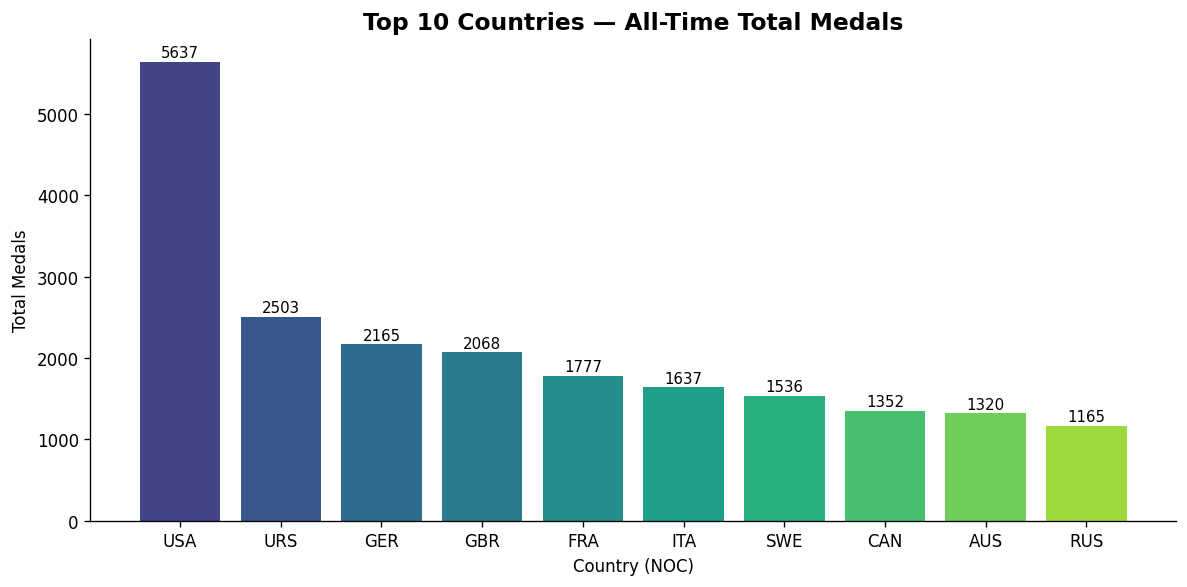

In [7]:
top_countries = (
    country_year.groupby('NOC')['Total_Medals']
    .sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_countries.index, top_countries.values,
              color=plt.cm.viridis(np.linspace(0.2, 0.85, 10)))
ax.set_title("Top 10 Countries — All-Time Total Medals", fontsize=14, fontweight='bold')
ax.set_xlabel("Country (NOC)")
ax.set_ylabel("Total Medals")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
            str(int(b.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


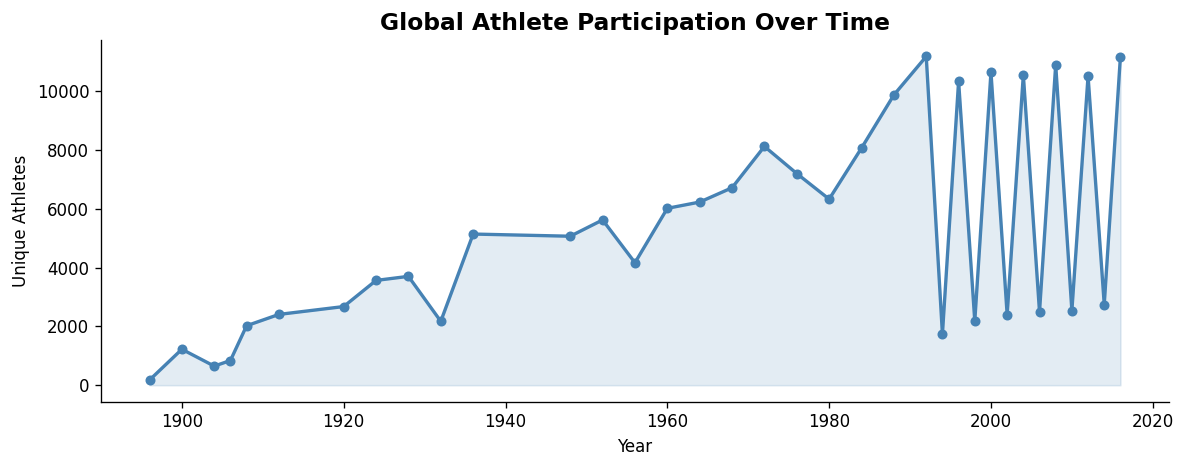

In [8]:
participation = df.groupby('Year')['ID'].nunique().reset_index()
participation.columns = ['Year', 'Unique_Athletes']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(participation['Year'], participation['Unique_Athletes'],
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(participation['Year'], participation['Unique_Athletes'], alpha=0.15, color='steelblue')
ax.set_title("Global Athlete Participation Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Unique Athletes")
plt.tight_layout()
plt.show()


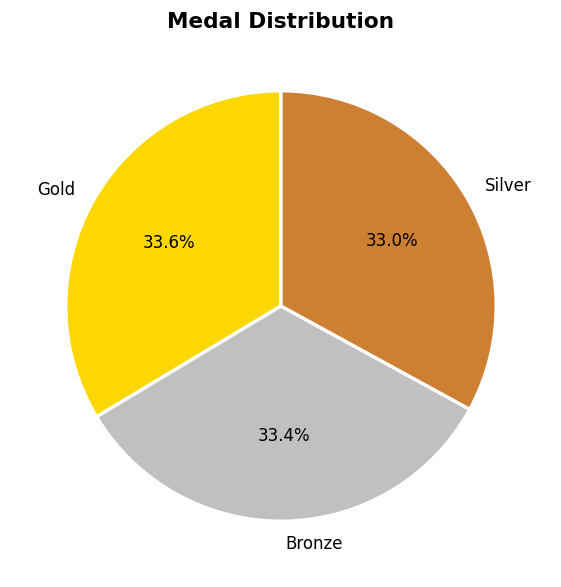

In [9]:
medal_counts = df[df['Medal'] != 'None']['Medal'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(medal_counts, labels=medal_counts.index,
       autopct='%1.1f%%', startangle=90,
       colors=['#FFD700', '#C0C0C0', '#CD7F32'],
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("Medal Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


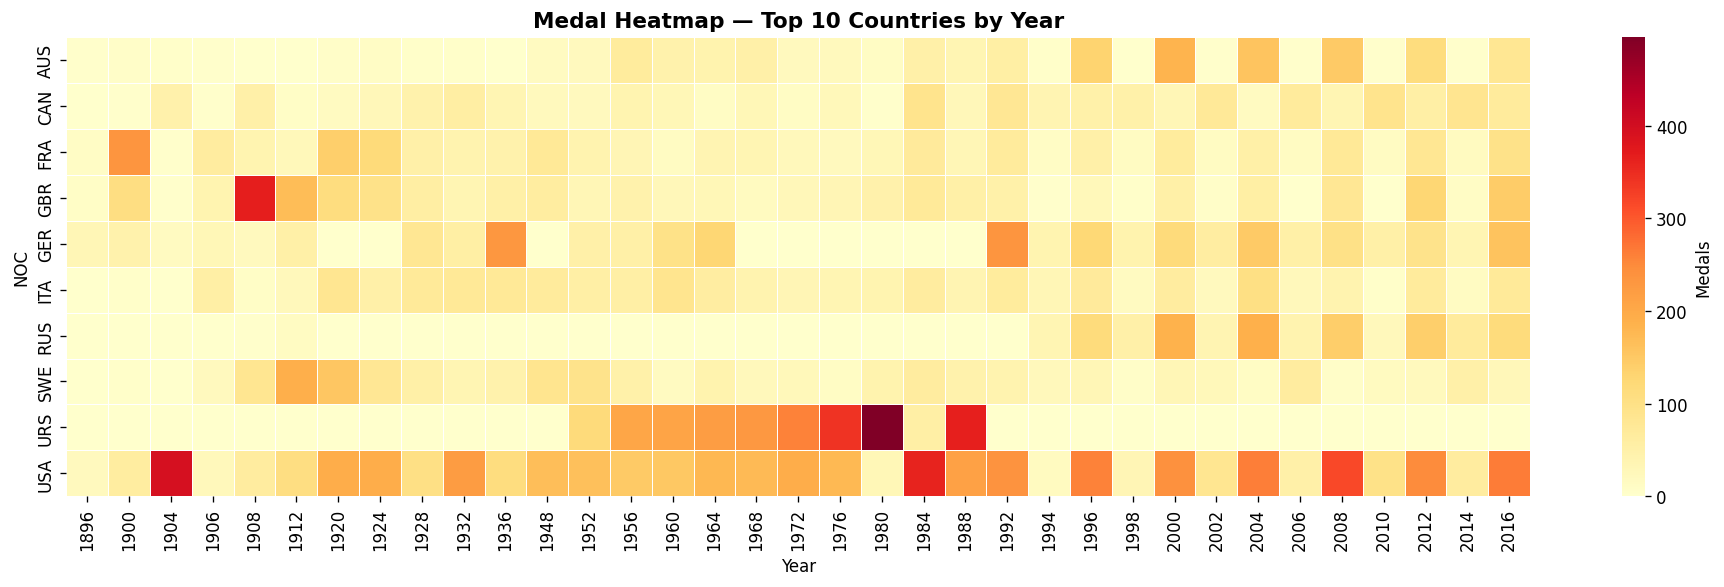

In [10]:
top10 = top_countries.index.tolist()
heatmap_data = (
    country_year[country_year['NOC'].isin(top10)]
    .pivot_table(index='NOC', columns='Year', values='Total_Medals', fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Medals'})
ax.set_title("Medal Heatmap — Top 10 Countries by Year", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


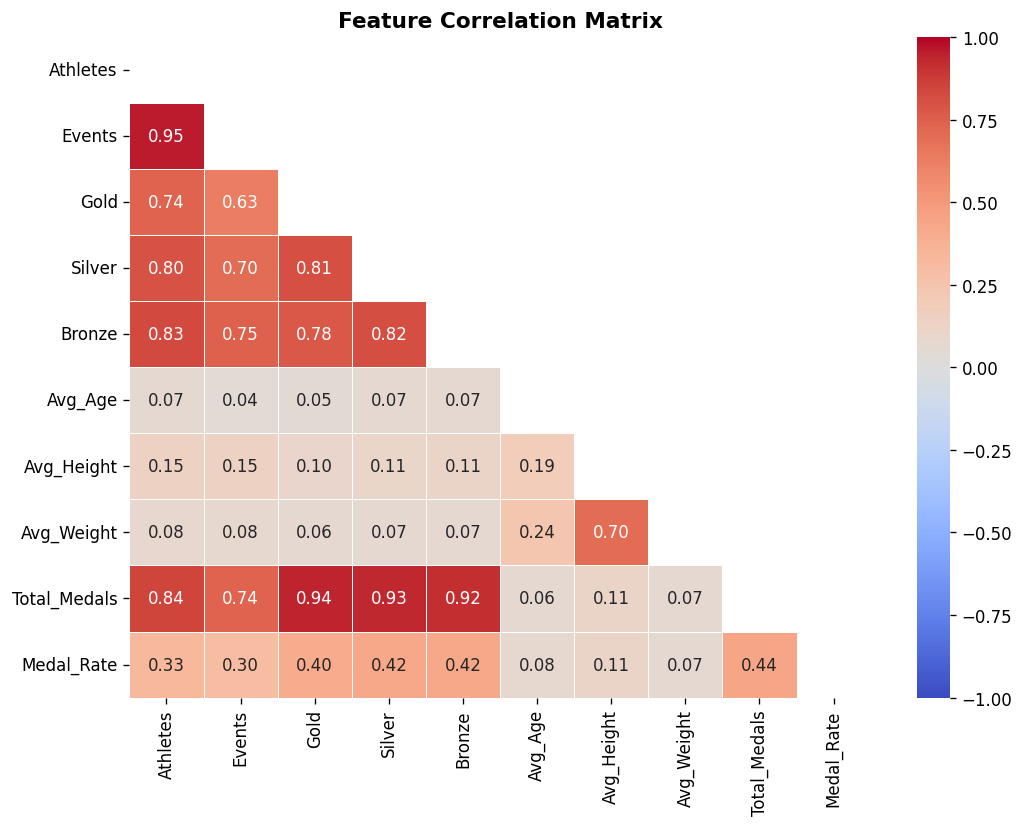

In [11]:
corr = country_year[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


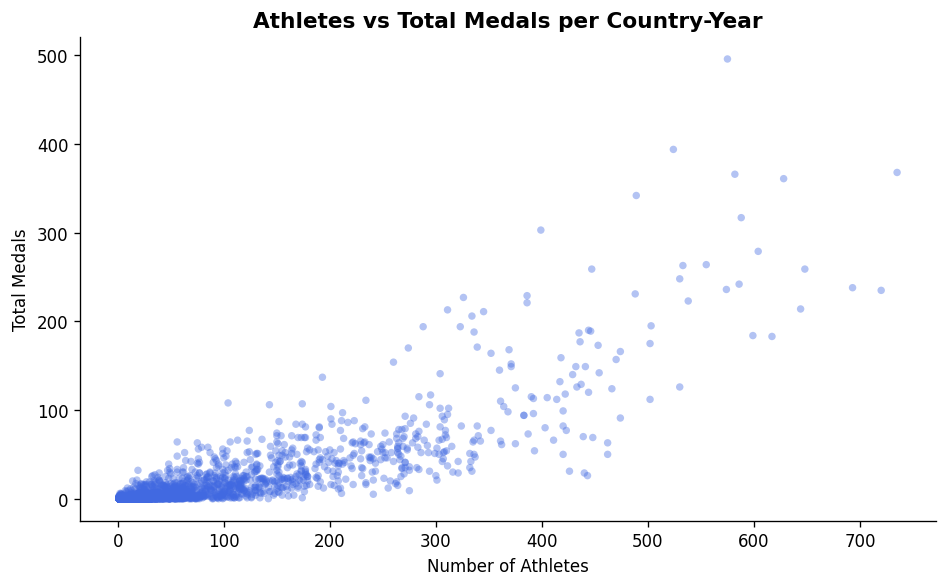

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(country_year['Athletes'], country_year['Total_Medals'],
           alpha=0.4, edgecolors='none', color='royalblue', s=20)
ax.set_title("Athletes vs Total Medals per Country-Year", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Athletes")
ax.set_ylabel("Total Medals")
plt.tight_layout()
plt.show()


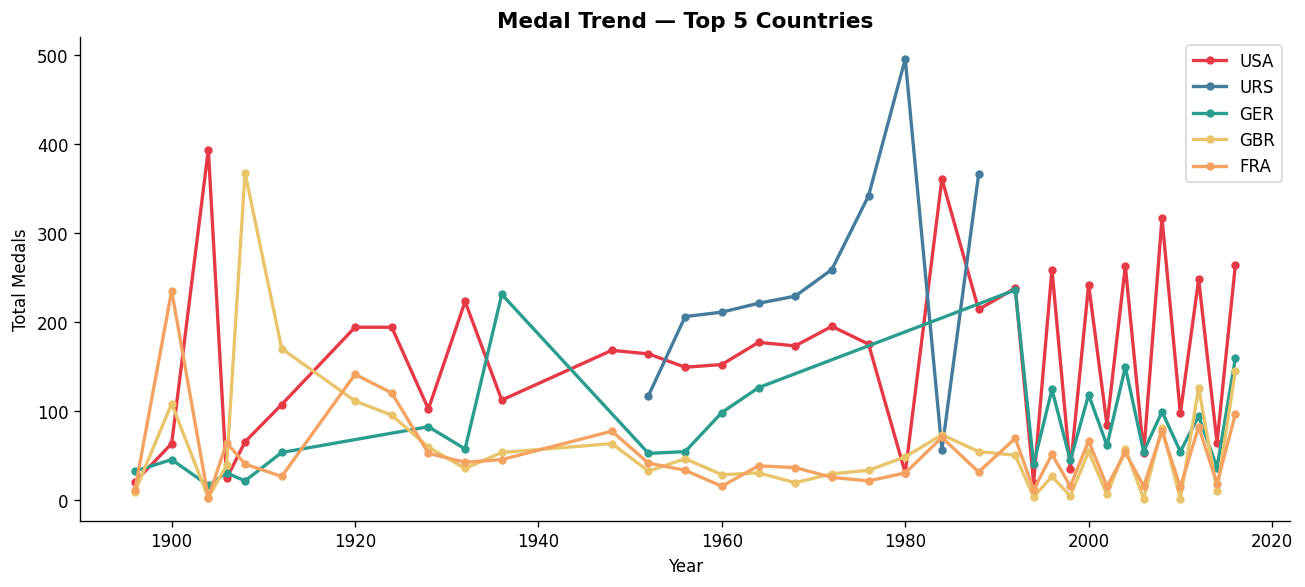

In [13]:
top5 = top_countries.head(5).index.tolist()
palette = ['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261']

fig, ax = plt.subplots(figsize=(11, 5))
for i, noc in enumerate(top5):
    d = country_year[country_year['NOC'] == noc].sort_values('Year')
    ax.plot(d['Year'], d['Total_Medals'], marker='o', markersize=4,
            linewidth=2, label=noc, color=palette[i])
ax.set_title("Medal Trend — Top 5 Countries", fontsize=13, fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Total Medals")
ax.legend()
plt.tight_layout()
plt.show()


---
## Phase 3 : Feature Selection

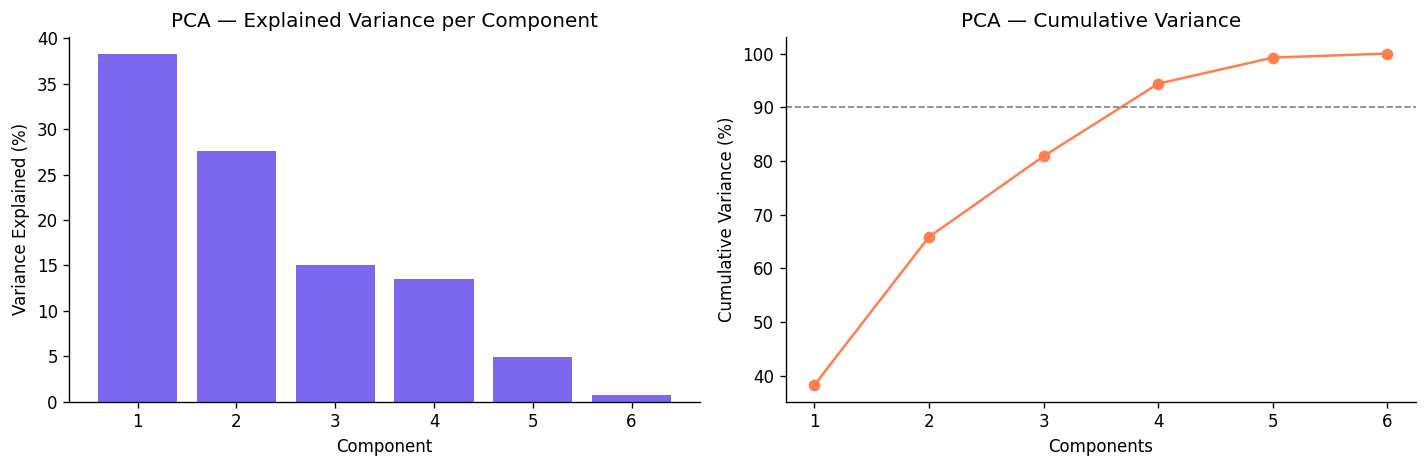

First 3 components explain 80.9% of variance.


In [14]:
X_fs = country_year[['Athletes', 'Events', 'Avg_Age', 'Avg_Height', 'Avg_Weight', 'Medal_Rate']].copy()
y_fs = country_year['Total_Medals'].values

X_fs_scaled = StandardScaler().fit_transform(X_fs)

pca = PCA(n_components=6)
pca.fit(X_fs_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 7), explained * 100, color='mediumslateblue')
axes[0].set_title("PCA — Explained Variance per Component")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance Explained (%)")

axes[1].plot(range(1, 7), np.cumsum(explained) * 100, marker='o', color='coral')
axes[1].axhline(90, ls='--', color='grey', lw=1)
axes[1].set_title("PCA — Cumulative Variance"); axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative Variance (%)")
plt.tight_layout(); plt.show()

print(f"First 3 components explain {np.cumsum(explained)[2]*100:.1f}% of variance.")


In [15]:
base_model = LinearRegression()
sfs_fwd = SequentialFeatureSelector(base_model, n_features_to_select=3,
                                     direction='forward', scoring='r2', cv=5)
sfs_fwd.fit(X_fs_scaled, y_fs)
fwd_mask = sfs_fwd.get_support()
fwd_features = [f for f, s in zip(X_fs.columns, fwd_mask) if s]
print("Forward Selection — selected features:", fwd_features)


Forward Selection — selected features: ['Athletes', 'Events', 'Medal_Rate']


In [16]:
sfs_bwd = SequentialFeatureSelector(base_model, n_features_to_select=3,
                                      direction='backward', scoring='r2', cv=5)
sfs_bwd.fit(X_fs_scaled, y_fs)
bwd_mask = sfs_bwd.get_support()
bwd_features = [f for f, s in zip(X_fs.columns, bwd_mask) if s]
print("Backward Elimination — selected features:", bwd_features)


Backward Elimination — selected features: ['Athletes', 'Events', 'Medal_Rate']


---
## Phase 4 : Model Building & Evaluation

### 4-A  Regression — Predicting Total Medal Count

In [17]:
reg_features = ['Athletes', 'Events', 'Avg_Age', 'Avg_Height', 'Avg_Weight', 'Medal_Rate']
X_reg = country_year[reg_features].values
y_reg = country_year['Total_Medals'].values

X_reg_sc = StandardScaler().fit_transform(X_reg)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg_sc, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_te)

rmse = np.sqrt(mean_squared_error(y_te, y_pred_lr))
r2   = r2_score(y_te, y_pred_lr)
print(f"Linear Regression  →  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")


Linear Regression  →  RMSE: 15.90  |  R²: 0.7662


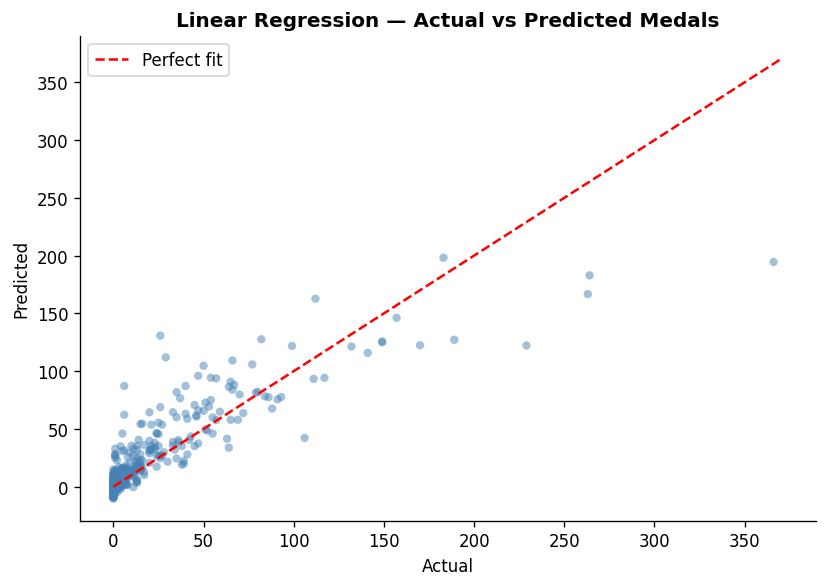

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_te, y_pred_lr, alpha=0.5, color='steelblue', edgecolors='none', s=25)
lims = [0, max(y_te.max(), y_pred_lr.max()) + 5]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax.set_title("Linear Regression — Actual vs Predicted Medals", fontsize=12, fontweight='bold')
ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
ax.legend(); plt.tight_layout(); plt.show()


### 4-B  Classification — Country Performance Category

In [19]:
# classify each country-year into Low / Medium / High
q33 = country_year['Total_Medals'].quantile(0.33)
q66 = country_year['Total_Medals'].quantile(0.66)

def categorize(m):
    if m <= q33: return 0    # Low
    elif m <= q66: return 1  # Medium
    else: return 2            # High

country_year['Perf_Category'] = country_year['Total_Medals'].apply(categorize)
print(country_year['Perf_Category'].value_counts().rename({0:'Low',1:'Medium',2:'High'}))


Perf_Category
Low       1863
High      1076
Medium     366
Name: count, dtype: int64


In [20]:
clf_features = ['Athletes', 'Events', 'Avg_Age', 'Avg_Height', 'Avg_Weight']
X_clf = country_year[clf_features].values
y_clf = country_year['Perf_Category'].values

X_clf_sc = StandardScaler().fit_transform(X_clf)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_clf_sc, y_clf, test_size=0.2,
                                                random_state=42, stratify=y_clf)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_tr2, y_tr2)
y_pred_lr2 = log_reg.predict(X_te2)

f1_lr2 = f1_score(y_te2, y_pred_lr2, average='weighted')
print(f"Logistic Regression  →  Weighted F1: {f1_lr2:.4f}")
print(classification_report(y_te2, y_pred_lr2, target_names=['Low','Medium','High']))


Logistic Regression  →  Weighted F1: 0.7533
              precision    recall  f1-score   support

         Low       0.79      0.96      0.87       373
      Medium       0.00      0.00      0.00        73
        High       0.83      0.79      0.81       215

    accuracy                           0.80       661
   macro avg       0.54      0.58      0.56       661
weighted avg       0.72      0.80      0.75       661



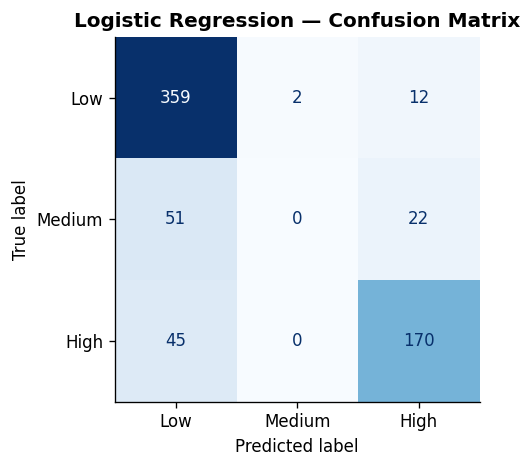

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_lr2, display_labels=['Low','Medium','High'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title("Logistic Regression — Confusion Matrix", fontweight='bold')
plt.tight_layout(); plt.show()


Best k = 10  |  CV F1 = 0.7720


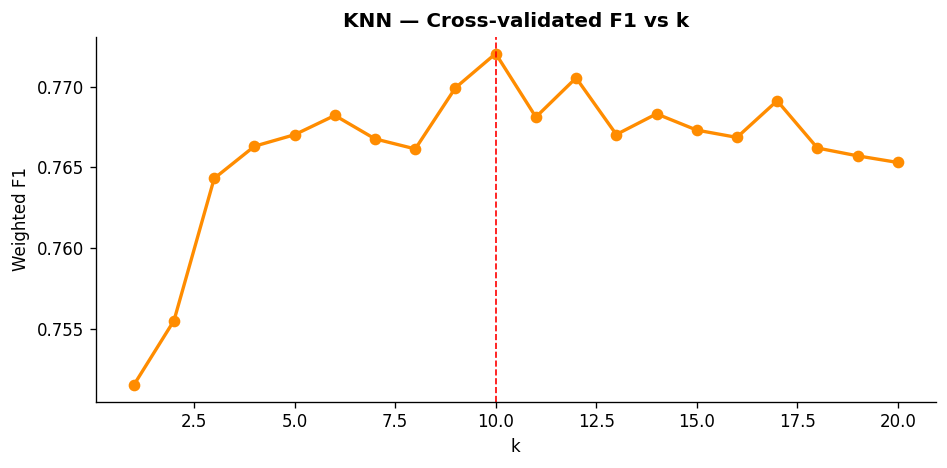

In [22]:
# tune k with cross-validation
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    s = cross_val_score(knn, X_tr2, y_tr2, cv=5, scoring='f1_weighted').mean()
    k_scores.append(s)

best_k = np.argmax(k_scores) + 1
print(f"Best k = {best_k}  |  CV F1 = {max(k_scores):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 21), k_scores, marker='o', color='darkorange', linewidth=2)
ax.axvline(best_k, color='red', ls='--', lw=1)
ax.set_title("KNN — Cross-validated F1 vs k", fontweight='bold')
ax.set_xlabel("k"); ax.set_ylabel("Weighted F1")
plt.tight_layout(); plt.show()


In [23]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_tr2, y_tr2)
y_pred_knn = knn_best.predict(X_te2)

f1_knn = f1_score(y_te2, y_pred_knn, average='weighted')
print(f"KNN (k={best_k})  →  Weighted F1: {f1_knn:.4f}")
print(classification_report(y_te2, y_pred_knn, target_names=['Low','Medium','High']))


KNN (k=10)  →  Weighted F1: 0.7569
              precision    recall  f1-score   support

         Low       0.78      0.95      0.86       373
      Medium       0.37      0.14      0.20        73
        High       0.84      0.71      0.77       215

    accuracy                           0.78       661
   macro avg       0.67      0.60      0.61       661
weighted avg       0.76      0.78      0.76       661



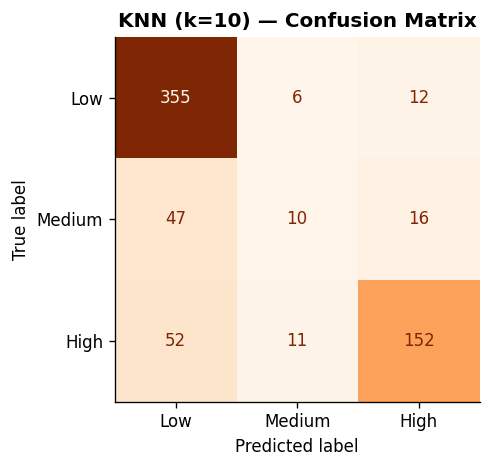

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_knn, display_labels=['Low','Medium','High'],
    cmap='Oranges', ax=ax, colorbar=False
)
ax.set_title(f"KNN (k={best_k}) — Confusion Matrix", fontweight='bold')
plt.tight_layout(); plt.show()


### 4-C  Clustering — K-Means (Unsupervised)

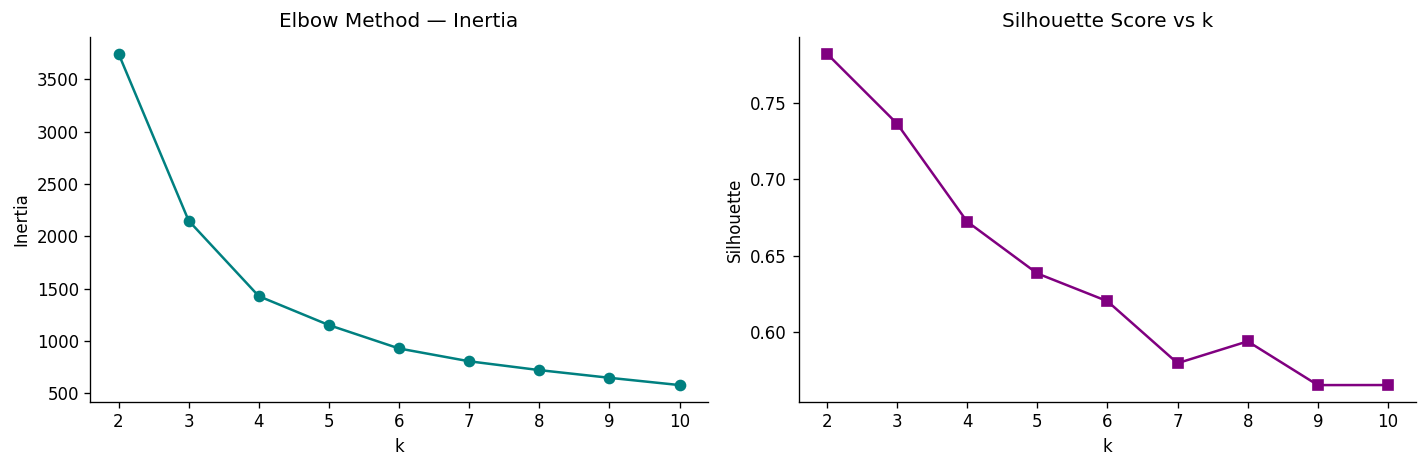

Best k (silhouette) = 2  |  Score = 0.7822


In [25]:
km_data = StandardScaler().fit_transform(country_year[['Athletes', 'Events', 'Total_Medals']])

inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(km_data)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(km_data, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o', color='teal')
axes[0].set_title("Elbow Method — Inertia"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, sil_scores, marker='s', color='purple')
axes[1].set_title("Silhouette Score vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

best_k_km = K_range[np.argmax(sil_scores)]
print(f"Best k (silhouette) = {best_k_km}  |  Score = {max(sil_scores):.4f}")


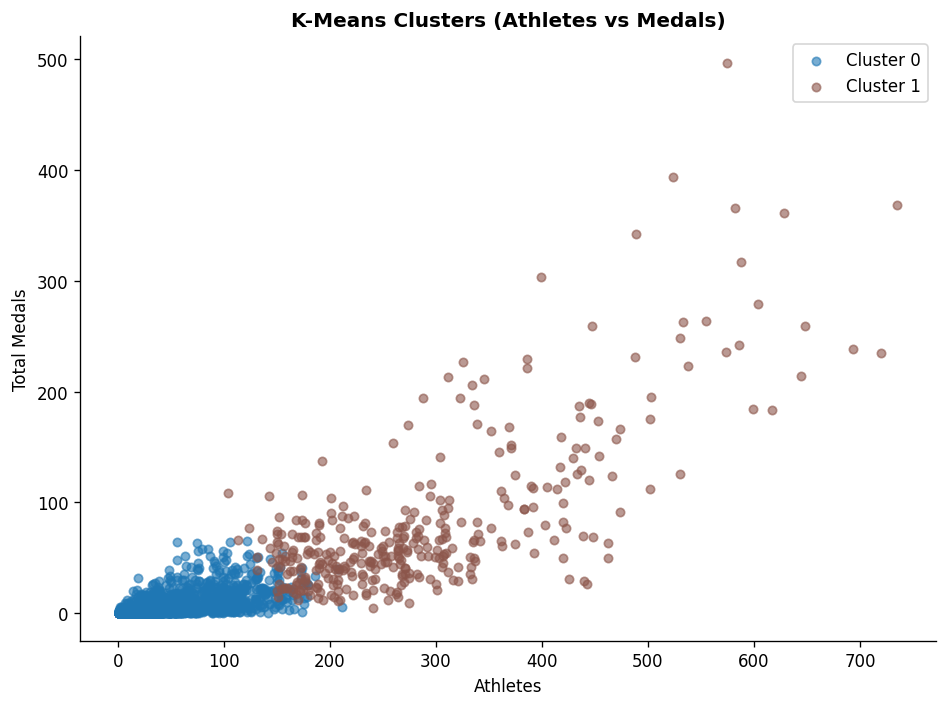

Cluster summary:
         Athletes  Events  Total_Medals
Cluster                                
0            29.0    21.0           3.6
1           285.6   147.2          81.6


In [26]:
km_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
country_year['Cluster'] = km_final.fit_predict(km_data)

palette_km = plt.cm.tab10(np.linspace(0, 0.5, best_k_km))
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k_km):
    mask = country_year['Cluster'] == c
    ax.scatter(country_year.loc[mask, 'Athletes'],
               country_year.loc[mask, 'Total_Medals'],
               label=f"Cluster {c}", alpha=0.6, s=25, color=palette_km[c])
ax.set_title("K-Means Clusters (Athletes vs Medals)", fontsize=12, fontweight='bold')
ax.set_xlabel("Athletes"); ax.set_ylabel("Total Medals")
ax.legend(); plt.tight_layout(); plt.show()

print("Cluster summary:")
print(country_year.groupby('Cluster')[['Athletes','Events','Total_Medals']].mean().round(1))


---
## Phase 5 : Model Comparison Summary

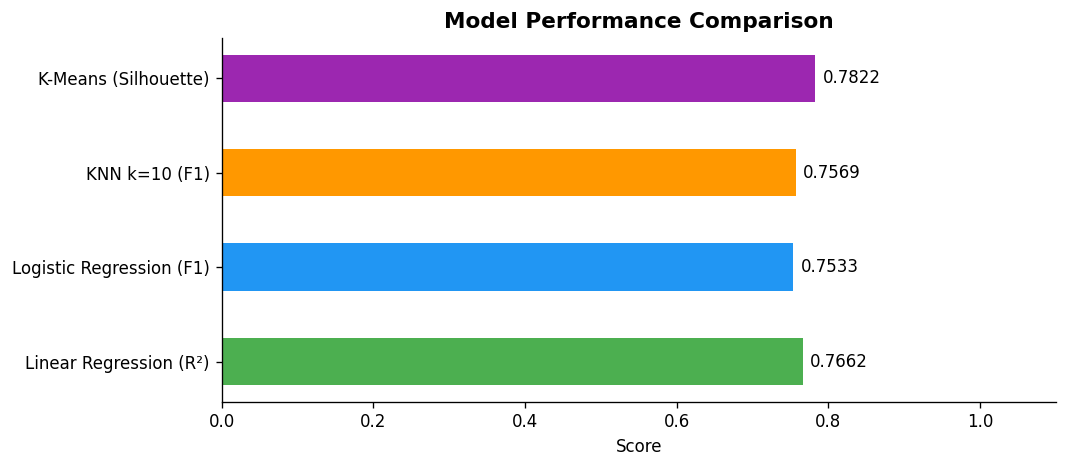


Final scores:
  Linear Regression (R²)             : 0.7662
  Logistic Regression (F1)           : 0.7533
  KNN k=10 (F1)                      : 0.7569
  K-Means (Silhouette)               : 0.7822


In [27]:
results = {
    'Linear Regression (R²)': r2,
    'Logistic Regression (F1)': f1_lr2,
    f'KNN k={best_k} (F1)': f1_knn,
    f'K-Means (Silhouette)': max(sil_scores),
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors, height=0.5)
ax.set_xlim(0, 1.1)
ax.set_title("Model Performance Comparison", fontsize=13, fontweight='bold')
ax.set_xlabel("Score")
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

print("\nFinal scores:")
for k, v in results.items():
    print(f"  {k:<35}: {v:.4f}")


---
## Phase 6 : Model Export — Save Trained Models

In [28]:
import pickle

In [29]:
# save best classification model (KNN)
with open('/Users/raj/Projects/PBL/best_model_olympic.pkl', 'wb') as f:
    pickle.dump(knn_best, f)
print("KNN model saved → best_model_olympic.pkl")


KNN model saved → best_model_olympic.pkl


In [30]:
# save the scaler used for classification features
clf_scaler = StandardScaler()
clf_scaler.fit(country_year[clf_features])

with open('/Users/raj/Projects/PBL/scaler_olympic.pkl', 'wb') as f:
    pickle.dump(clf_scaler, f)
print("Scaler saved → scaler_olympic.pkl")


Scaler saved → scaler_olympic.pkl


In [31]:
# save the backward feature selector
with open('/Users/raj/Projects/PBL/feature_selector_olympic.pkl', 'wb') as f:
    pickle.dump(sfs_bwd, f)
print("Feature selector saved → feature_selector_olympic.pkl")


Feature selector saved → feature_selector_olympic.pkl


In [32]:
# also save the linear regression model
with open('/Users/raj/Projects/PBL/linear_reg_olympic.pkl', 'wb') as f:
    pickle.dump(lr, f)
print("Linear Regression model saved → linear_reg_olympic.pkl")


Linear Regression model saved → linear_reg_olympic.pkl


---
## Phase 7 : Sample Prediction Demo

In [33]:
# load models back and run a sample prediction
with open('/Users/raj/Projects/PBL/best_model_olympic.pkl', 'rb') as f:
    loaded_knn = pickle.load(f)

with open('/Users/raj/Projects/PBL/scaler_olympic.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# sample: a country sends 300 athletes, competes in 25 events
#         avg age 26, avg height 178, avg weight 75
sample = {
    'Athletes':   300,
    'Events':     25,
    'Avg_Age':    26.0,
    'Avg_Height': 178.0,
    'Avg_Weight': 75.0,
}

import numpy as np
sample_df = pd.DataFrame([sample])
sample_scaled = loaded_scaler.transform(sample_df)

pred_class = loaded_knn.predict(sample_scaled)[0]
label_map  = {0: 'Low', 1: 'Medium', 2: 'High'}

print("=== Sample Prediction ===")
for k, v in sample.items():
    print(f"  {k:<15}: {v}")
print(f"\nPredicted Performance Category: {label_map[pred_class]}")


=== Sample Prediction ===
  Athletes       : 300
  Events         : 25
  Avg_Age        : 26.0
  Avg_Height     : 178.0
  Avg_Weight     : 75.0

Predicted Performance Category: High


In [34]:
# regression prediction — estimated total medal count
with open('/Users/raj/Projects/PBL/linear_reg_olympic.pkl', 'rb') as f:
    loaded_lr = pickle.load(f)

reg_scaler = StandardScaler()
reg_scaler.fit(country_year[reg_features])

sample_reg = {
    'Athletes':   300,
    'Events':     25,
    'Avg_Age':    26.0,
    'Avg_Height': 178.0,
    'Avg_Weight': 75.0,
    'Medal_Rate': 0.15,
}

sample_reg_df  = pd.DataFrame([sample_reg])
sample_reg_sc  = reg_scaler.transform(sample_reg_df)
pred_medals    = loaded_lr.predict(sample_reg_sc)[0]

print(f"Estimated Medal Count (Linear Regression): {pred_medals:.1f} medals")


Estimated Medal Count (Linear Regression): 151.9 medals
